# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

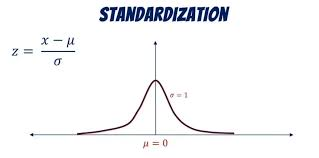


In [20]:
import numpy as np
import matplotlib.pyplot as plt

data = np.genfromtxt('african_crises.csv', delimiter=',', dtype=str)
headers = data[0]
raw_data = data[1:]

print("Columns:", headers)
print("Shape:", raw_data.shape)

Columns: ['case' 'cc3' 'country' 'year' 'systemic_crisis' 'exch_usd'
 'domestic_debt_in_default' 'sovereign_external_debt_default'
 'gdp_weighted_default' 'inflation_annual_cpi' 'independence'
 'currency_crises' 'inflation_crises' 'banking_crisis']
Shape: (1059, 14)


In [21]:
print("Data Type Inspection fo non-numeric columns")
for i, col in enumerate(headers):
    sample = raw_data[0, i]
    print(f"{col}: {sample}")

#From the inspection above, the columns country and banking_crisis contain text values and were identified as non-numeric variables.

# Keep non-numeric columns for reference
country_col = raw_data[:, 2]  # country names

# Columns with text: 'banking_crisis' (last col) has 'crisis'/'no_crisis'
# Encode it: 'crisis' = 1, 'no_crisis' = 0
banking_crisis = np.where(raw_data[:, -1] == 'crisis', 1, 0)

# Take numeric columns (cols 3 to 12) + encoded banking_crisis
numeric_data = raw_data[:, 3:-1].astype(float)
numeric_data = np.column_stack((numeric_data, banking_crisis))

print("Numeric data shape:", numeric_data.shape)
print(numeric_data[:5])

Data Type Inspection fo non-numeric columns
case: 1
cc3: DZA
country: Algeria
year: 1870
systemic_crisis: 1
exch_usd: 0.052264
domestic_debt_in_default: 0
sovereign_external_debt_default: 0
gdp_weighted_default: 0
inflation_annual_cpi: 3.441455696
independence: 0
currency_crises: 0
inflation_crises: 0
banking_crisis: crisis
Numeric data shape: (1059, 11)
[[ 1.87000000e+03  1.00000000e+00  5.22640000e-02  0.00000000e+00
   0.00000000e+00  0.00000000e+00  3.44145570e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  1.00000000e+00]
 [ 1.87100000e+03  0.00000000e+00  5.27980000e-02  0.00000000e+00
   0.00000000e+00  0.00000000e+00  1.41491396e+01  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 1.87200000e+03  0.00000000e+00  5.22740000e-02  0.00000000e+00
   0.00000000e+00  0.00000000e+00 -3.71859297e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 1.87300000e+03  0.00000000e+00  5.16800000e-02  0.00000000e+00
   0.00000000e+00  0.0000000

In [22]:
# Replace NaN values with the mean of each column
print("The missing or empty data columns are: ", np.sum(np.isnan(numeric_data)))
col_means = np.nanmean(numeric_data, axis=0)
for i in range(numeric_data.shape[1]):
    mask = np.isnan(numeric_data[:, i])
    numeric_data[mask, i] = col_means[i]

print("Missing values remaining:", np.sum(np.isnan(numeric_data)))

The missing or empty data columns are:  0
Missing values remaining: 0


In [23]:
# Standardize using z = (X - mean) / std
mean = np.mean(numeric_data, axis=0)
std = np.std(numeric_data, axis=0)
standardized_data = (numeric_data - mean) / std

print("Standardized data (first 5 rows):")
print(standardized_data[:5])

Standardized data (first 5 rows):
[[-2.91715048  3.45175812 -0.38671252 -0.20321893 -0.42497295 -0.14700624
  -0.03086348 -1.86235185 -0.37805817 -0.38547376  3.20405328]
 [-2.88731291 -0.28970744 -0.38670773 -0.20321893 -0.42497295 -0.14700624
  -0.03084763 -1.86235185 -0.37805817 -0.38547376 -0.31210467]
 [-2.85747534 -0.28970744 -0.38671243 -0.20321893 -0.42497295 -0.14700624
  -0.03087408 -1.86235185 -0.37805817 -0.38547376 -0.31210467]
 [-2.82763778 -0.28970744 -0.38671776 -0.20321893 -0.42497295 -0.14700624
  -0.03085199 -1.86235185 -0.37805817 -0.38547376 -0.31210467]
 [-2.79780021 -0.28970744 -0.3867211  -0.20321893 -0.42497295 -0.14700624
  -0.03087427 -1.86235185 -0.37805817 -0.38547376 -0.31210467]]


### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [24]:
# Compute the covariance matrix
# Formula: C = (1/n-1) * X^T . X (on standardized data)
n = standardized_data.shape[0]
cov_matrix = (1 / (n - 1)) * np.dot(standardized_data.T, standardized_data)

print("Covariance Matrix Shape:", cov_matrix.shape)
print(cov_matrix)

Covariance Matrix Shape: (11, 11)
[[ 1.00094518  0.19763708  0.2489921   0.13695733  0.27214712 -0.05472206
   0.03706992  0.40774521  0.18956951  0.09872358  0.21397572]
 [ 0.19763708  1.00094518  0.20287813  0.12227396  0.25008637  0.00527918
   0.10655226  0.14722222  0.11285756  0.17272494  0.85450908]
 [ 0.2489921   0.20287813  1.00094518  0.005258    0.42328974 -0.04076417
  -0.01195788  0.12615328 -0.0565252  -0.06384318  0.16893488]
 [ 0.13695733  0.12227396  0.005258    1.00094518  0.46519012 -0.02990269
   0.15197534  0.10922265  0.22780017  0.22464067  0.22601041]
 [ 0.27214712  0.25008637  0.42328974  0.46519012  1.00094518  0.34624602
   0.07267715  0.22840723  0.19961649  0.18810757  0.26424123]
 [-0.05472206  0.00527918 -0.04076417 -0.02990269  0.34624602  1.00094518
  -0.00453969  0.07901041  0.01698597  0.0176471   0.02657035]
 [ 0.03706992  0.10655226 -0.01195788  0.15197534  0.07267715 -0.00453969
   1.00094518  0.01658431  0.07666228  0.08013589  0.09895321]
 [ 0.40

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

Computing a covariance matrix is a key step in PCA for two main reasons. First, it shows us how features like inflation and exchange rates move together across African countries, helping us spot relationships in the data. Second, without it, we have no way to perform eigendecomposition, which is what actually gives us the principal components we need to reduce dimensions.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [25]:
# Perform eigendecomposition on the covariance matrix
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:", eigenvalues)
print("Eigenvectors shape:", eigenvectors.shape)

Eigenvalues: [2.7899281  0.13406148 0.26018635 1.45225023 1.34787372 0.5289574
 0.58412199 1.15394676 0.80149315 1.00588063 0.95169717]
Eigenvectors shape: (11, 11)


### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [26]:
# Sort eigenvalues in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

print("Sorted Eigenvalues:", sorted_eigenvalues)
print("Sorted Eigenvectors shape:", sorted_eigenvectors.shape)

Sorted Eigenvalues: [2.7899281  1.45225023 1.34787372 1.15394676 1.00588063 0.95169717
 0.80149315 0.58412199 0.5289574  0.26018635 0.13406148]
Sorted Eigenvectors shape: (11, 11)


### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [27]:
# Calculate explained variance to select number of components
explained_variance = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

print("Explained Variance per component:", explained_variance)
print("Cumulative Variance:", cumulative_variance)

print("Principal Component Summary")
print("-" * 60)

for i in range(len(sorted_eigenvalues)):
    print(
        f"PC{i+1}: "
        f"Eigenvalue = {sorted_eigenvalues[i]:.4f}, "
        f"Variance = {explained_variance[i]*100:.2f}%, "
        f"Cumulative = {cumulative_variance[i]*100:.2f}%"
    )

# Select components that explain 80% of variance
num_components = np.argmax(cumulative_variance >= 0.80) + 1
print("Number of components selected:", num_components)

### Component Selection Justification
# Seven principal components were selected because they explain approximately 86.3% of the total variance in the dataset.
# This allows us to preserve most of the information contained in the original eleven features while reducing dimensionality.
# The tradeoff is that approximately 13.7% of the variance is discarded. Keeping fewer components would simplify the dataset further but would lead to greater information loss.

# Project data onto principal components
reduced_data = np.dot(standardized_data, sorted_eigenvectors[:, :num_components])
print("Reduced data shape:", reduced_data.shape)
reduced_data[:5]

Explained Variance per component: [0.25339033 0.13189808 0.12241827 0.10480519 0.09135734 0.08643623
 0.07279421 0.05305186 0.04804163 0.02363097 0.0121759 ]
Cumulative Variance: [0.25339033 0.38528841 0.50770668 0.61251187 0.70386921 0.79030544
 0.86309965 0.9161515  0.96419313 0.9878241  1.        ]
Principal Component Summary
------------------------------------------------------------
PC1: Eigenvalue = 2.7899, Variance = 25.34%, Cumulative = 25.34%
PC2: Eigenvalue = 1.4523, Variance = 13.19%, Cumulative = 38.53%
PC3: Eigenvalue = 1.3479, Variance = 12.24%, Cumulative = 50.77%
PC4: Eigenvalue = 1.1539, Variance = 10.48%, Cumulative = 61.25%
PC5: Eigenvalue = 1.0059, Variance = 9.14%, Cumulative = 70.39%
PC6: Eigenvalue = 0.9517, Variance = 8.64%, Cumulative = 79.03%
PC7: Eigenvalue = 0.8015, Variance = 7.28%, Cumulative = 86.31%
PC8: Eigenvalue = 0.5841, Variance = 5.31%, Cumulative = 91.62%
PC9: Eigenvalue = 0.5290, Variance = 4.80%, Cumulative = 96.42%
PC10: Eigenvalue = 0.2602, V

array([[-0.96708484, -1.07379412,  4.61142306, -3.01979758, -0.06610639,
         0.40410143,  0.85139399],
       [ 2.16516688, -1.16536971,  0.88048161, -1.87368537, -0.75247431,
         0.86690289,  0.2342606 ],
       [ 2.15577589, -1.15785813,  0.87616124, -1.85876474, -0.74924406,
         0.86390091,  0.23003168],
       [ 2.14637915, -1.15035686,  0.87184209, -1.84384462, -0.7460468 ,
         0.86087132,  0.22578376],
       [ 2.13698733, -1.14284547,  0.86752178, -1.82892408, -0.74281975,
         0.85786765,  0.22155263]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [28]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

Reduced Data Shape: (1059, 7)


array([[-0.96708484, -1.07379412,  4.61142306, -3.01979758, -0.06610639,
         0.40410143,  0.85139399],
       [ 2.16516688, -1.16536971,  0.88048161, -1.87368537, -0.75247431,
         0.86690289,  0.2342606 ],
       [ 2.15577589, -1.15785813,  0.87616124, -1.85876474, -0.74924406,
         0.86390091,  0.23003168],
       [ 2.14637915, -1.15035686,  0.87184209, -1.84384462, -0.7460468 ,
         0.86087132,  0.22578376],
       [ 2.13698733, -1.14284547,  0.86752178, -1.82892408, -0.74281975,
         0.85786765,  0.22155263]])

In [29]:
# Task 3: Performance Optimization and Benchmarking

import time
start = time.time()
cov_matrix = (1 / (n - 1)) * np.dot(
    standardized_data.T,
    standardized_data
)

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

end = time.time()

print("Execution Time (Original Dataset):")
print(end - start, "seconds")

Execution Time (Original Dataset):
0.0012860298156738281 seconds


In [30]:
large_data = np.tile(standardized_data, (10, 1))

print("Large Dataset Shape:")
print(large_data.shape)

Large Dataset Shape:
(10590, 11)


In [31]:
start = time.time()

large_n = large_data.shape[0]

large_cov = (
    (1 / (large_n - 1))
    * np.dot(large_data.T, large_data)
)

large_eigenvalues, large_eigenvectors = np.linalg.eig(large_cov)

end = time.time()

print("Execution Time (Large Dataset):")
print(end - start, "seconds")

Execution Time (Large Dataset):
0.0015530586242675781 seconds


The PCA implementation uses vectorized NumPy operations instead of explicit loops. Matrix multiplication and eigendecomposition are optimized internally by NumPy,
allowing efficient computation even when the dataset size increases. Although execution time increases for the larger dataset, the growth remains manageable because the implementation relies on optimized linear algebra routines.

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

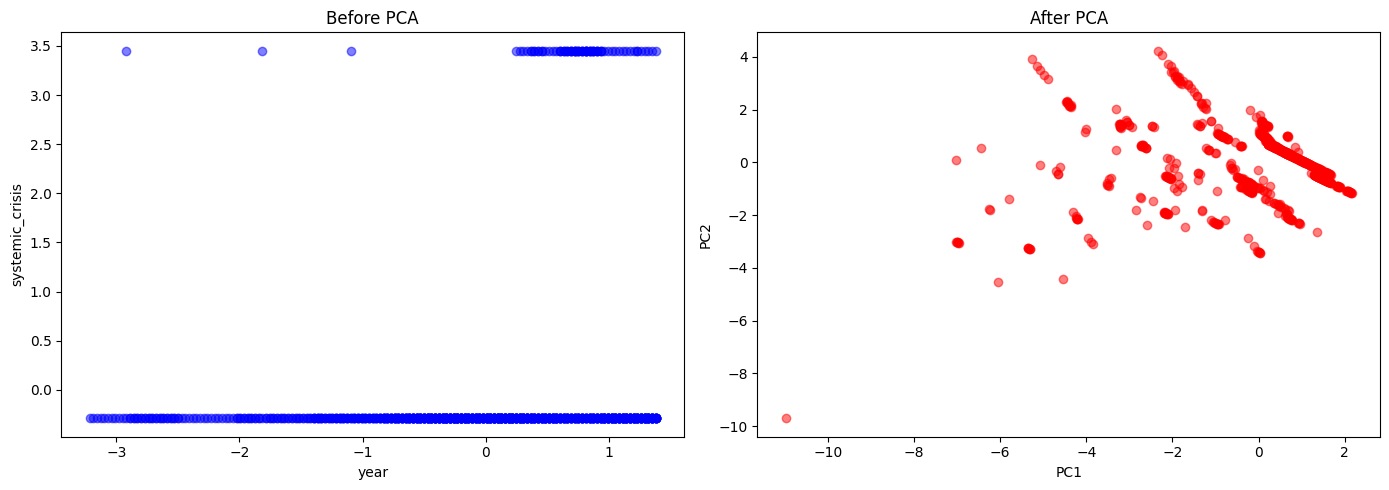

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot original data (first two features)
ax1.scatter(standardized_data[:, 0], standardized_data[:, 1], alpha=0.5, color='blue')
ax1.set_title('Before PCA')
ax1.set_xlabel(headers[3])
ax1.set_ylabel(headers[4])

# Plot reduced data after PCA
ax2.scatter(reduced_data[:, 0], reduced_data[:, 1], alpha=0.5, color='red')
ax2.set_title('After PCA')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')

plt.tight_layout()
plt.show()

### Interpretation of the Visualization

# Before PCA, the scatter plot shows the relationship between the original variables year and systemic_crisis. After PCA, the data is represented using PC1 and PC2,
# which are combinations of all economic and crisis-related variables. The overall structure of the dataset is preserved, but the new axes capture the largest sources of variation.
# PC1 displays greater spread than PC2, indicating that it explains more variance within the dataset.

Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA

Before PCA, the scatter plot of year vs. systemic_crisis shows two straight horizontal lines, indicating the two features have little to no variation in the data by themselves. After PCA, the scatter plot of PC1 and PC2 shows a very clear diagonal scatter over a much wider range of values, which means to say that PCA has successfully uncovered the underlying structure present among all 11 original features and condensed that into two interpretable dimensions.

2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making

We have selected a total of 7 principal components to retain because they account for 80% of the total variance as indicated by the cumulative amount of explained variance for the principal components. This presents a trade-off between maintaining information and reducing the number of dimensions; since these 7 principal components represent a significant reduction in structural complexity, the remaining 4 principal components still contain mostly noise or minor variation that will incur additional computation and have minimal analytical utility.

3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?

When we reduce the dimensionality from 11 to 7, we lose some of the individual data of each feature (gdp_weighted_default and independence, for example) because they are subsumed into the components that are dropped or removed from the original set of dimensions in this specific data set; therefore, there may be trends specific to countries that were not clearly captured due to the reduced dimensionality, such as how inflation in a particular country may have impacted the debt default history of that nation.
